# Hyperparameter Grid Search

This notebook contains code to perform grid searches over hyperparameter combinations for the various training algorithms tested for this project

In [1]:
import warnings
import logging
import itertools
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from data import build_random_dag, generate_random_dataset, load_sachs_data, load_sachs_ground_truth
from training import learn_dag

logging.getLogger('castle').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
2026-04-13 19:31:59,487 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\backend\__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-04-13 19:31:59,642 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


##### Training code

In [2]:
def _edge_metrics(true_edges: set, learned_edges: set) -> dict:
    """Directed-edge recovery metrics: SHD, precision, recall, F1.

    Reversed edges (u→v learned when v→u is true) count as one mistake in SHD
    and are excluded from TP for both precision and recall.
    """
    reversed_edges = {(v, u) for u, v in true_edges} & learned_edges
    tp  = len(true_edges & learned_edges)
    fp  = len(learned_edges - true_edges - reversed_edges)
    fn  = len(true_edges - learned_edges - {(v, u) for u, v in reversed_edges})
    rev = len(reversed_edges)
    shd = fp + fn + rev
    precision = tp / (tp + fp + rev) if (tp + fp + rev) > 0 else 0.0
    recall    = tp / (tp + fn + rev) if (tp + fn + rev) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"shd": shd, "precision": precision, "recall": recall, "f1": f1}


_LOWER_IS_BETTER = {"shd"}


def grid_search(data, algorithm: str, param_grid: dict, gt_dag, metric: str = "shd"):
    """Grid search over all combinations in param_grid.

    For each combination the algorithm is run on *data* and the resulting
    edges are scored against *gt_dag*.

    Args:
        data:       Training dataset (pd.DataFrame).
        algorithm:  Algorithm name forwarded to learn_dag.
        param_grid: Mapping of parameter name → list of candidate values.
        gt_dag:     Ground-truth DAG (networkx DiGraph).
        metric:     Metric used to select the best result ("shd", "f1",
                    "precision", or "recall"). Defaults to "shd".

    Returns:
        best_result: TrainingResult for the combination with the best score on metric.
        results_df:  DataFrame with one row per parameter combination,
                     columns = param names + [n_learned, shd, precision, recall, f1].
    """
    true_edges       = set(gt_dag.edges())
    param_names      = list(param_grid.keys())
    rows             = []
    lower_is_better  = metric in _LOWER_IS_BETTER
    best_result      = None
    best_val         = float("inf") if lower_is_better else -1.0

    n_combos = 1
    for v in param_grid.values():
        n_combos *= len(v)
    print(f"Grid: {' × '.join(str(len(v)) for v in param_grid.values())} = {n_combos} combinations\n")

    for param_values in itertools.product(*param_grid.values()):
        params = dict(zip(param_names, param_values))
        result = learn_dag(data, algorithm, **params)
        m      = _edge_metrics(true_edges, result.edges)
        rows.append({**params, "n_learned": len(result.edges), **m})
        val = m[metric]
        if (val < best_val) if lower_is_better else (val > best_val):
            best_val, best_result = val, result

    return best_result, pd.DataFrame(rows)

##### Reporting code

In [3]:
_METRICS      = ["shd", "precision", "recall", "f1", "n_learned"]
_METRIC_PLOTS = [
    ("f1",        "F1 ↑",        "YlGn",    False),
    ("shd",       "SHD ↓",       "YlOrRd",  True),
    ("precision", "Precision ↑", "Blues",   False),
    ("recall",    "Recall ↑",    "Purples", False),
]


def _marginal(results_df, param_grid, row_param, col_param):
    """Average metrics over all parameters except the given pair."""
    other = [p for p in param_grid if p not in (row_param, col_param)]
    return (
        results_df.groupby([row_param, col_param])[_METRICS].mean().reset_index()
        if other else results_df
    )


def plot_heatmaps(results_df, param_grid):
    """One 2×2 heatmap figure per pair of parameters in param_grid.
    Extra parameters beyond the pair are averaged out."""
    for row_param, col_param in combinations(param_grid.keys(), 2):
        df   = _marginal(results_df, param_grid, row_param, col_param)
        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
        for ax, (col, label, cmap, reverse) in zip(axes.flatten(), _METRIC_PLOTS):
            pivot = df.pivot(index=row_param, columns=col_param, values=col)
            sns.heatmap(
                pivot, ax=ax,
                cmap=cmap + "_r" if reverse else cmap,
                annot=pivot.round(2), fmt=".2f",
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": label},
                vmin=pivot.values.min(), vmax=pivot.values.max(),
            )
            ax.set_title(label, fontsize=12, fontweight="bold")
            ax.set_xlabel(col_param)
            ax.set_ylabel(row_param)
        other = [p for p in param_grid if p not in (row_param, col_param)]
        extra = f"  (avg over: {', '.join(other)})" if other else ""
        fig.suptitle(f"{row_param} × {col_param}{extra}", fontsize=13, y=1.01)
        fig.tight_layout()
        fname = f"notears_gridsearch_heatmaps_{row_param}_x_{col_param}.png"
        plt.show()


def plot_line_profiles(results_df, param_grid, best_params):
    """F1 and SHD vs each individual parameter, all others fixed at best values."""
    param_names = list(param_grid.keys())
    colors = ["steelblue", "darkorange", "seagreen", "orchid"]
    fig, axes = plt.subplots(2, len(param_names),
                             figsize=(5 * len(param_names), 8),
                             squeeze=False)
    for col_idx, param in enumerate(param_names):
        mask = pd.Series(True, index=results_df.index)
        for other, val in best_params.items():
            if other != param:
                if pd.isna(val) if not isinstance(val, (list, dict)) else False:
                    mask &= results_df[other].isna()
                else:
                    mask &= results_df[other] == val
        slice_df  = results_df[mask].sort_values(param, na_position="last")
        fixed_str = ", ".join(f"{k}={v}" for k, v in best_params.items() if k != param)
        x_labels  = slice_df[param].apply(lambda v: "None" if pd.isna(v) else str(v))
        for row_idx, (metric, label) in enumerate([("f1", "F1"), ("shd", "SHD")]):
            ax = axes[row_idx][col_idx]
            ax.plot(x_labels, slice_df[metric],
                    marker="o", color=colors[col_idx % len(colors)])
            ax.set_title(f"{label} vs {param}\n({fixed_str})", fontsize=9)
            ax.set_xlabel(param)
            ax.set_ylabel(label)
            ax.grid(axis="y", alpha=0.4)
    fig.suptitle("Effect of each hyperparameter  (others fixed at best values)", fontsize=13)
    fig.tight_layout()
    plt.show()


def plot_scatter(results_df, param_grid):
    """Precision–Recall scatter for all combinations.
    First two params drive color/marker; any extras are averaged out.
    Bubble size is proportional to SHD (smaller = better)."""
    param_names = list(param_grid.keys())
    p0, p1 = param_names[0], param_names[1]
    df     = _marginal(results_df, param_grid, p0, p1)
    p0_vals = sorted(df[p0].unique())
    p1_vals = sorted(df[p1].unique())
    colors  = plt.cm.tab10(np.linspace(0, 1, len(p0_vals)))
    markers = ["o", "s", "^", "D", "v", "P"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for p0_idx, p0_val in enumerate(p0_vals):
        for _, row in df[df[p0] == p0_val].iterrows():
            p1_idx = p1_vals.index(row[p1])
            ax.scatter(row["precision"], row["recall"],
                       s=row["shd"] * 6 + 20,
                       color=colors[p0_idx],
                       marker=markers[p1_idx % len(markers)],
                       alpha=0.8, edgecolors="white", linewidths=0.5)
            ax.annotate(f"({p0_val},{row[p1]})",
                        (row["precision"], row["recall"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.7)
    other = [p for p in param_names if p not in (p0, p1)]
    extra = f"  (avg over: {', '.join(other)})" if other else ""
    ax.set_title(f"Precision–Recall: {p0} × {p1}{extra}\n(bubble ∝ SHD)", fontsize=12)
    ax.set_xlabel("Precision"); ax.set_ylabel("Recall")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="grey", lw=0.5, ls="--")
    ax.axvline(0.5, color="grey", lw=0.5, ls="--")
    ax.grid(alpha=0.3)
    handles = [mpatches.Patch(color=colors[i], label=f"{p0}={v}") for i, v in enumerate(p0_vals)]
    ax.legend(handles=handles, title=p0, fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()


def print_summary(results_df, param_grid, n=5, metric: str = "shd"):
    """Print the top-n combinations by the target metric and state the recommendation."""
    param_names     = list(param_grid.keys())
    ascending       = metric in _LOWER_IS_BETTER
    top  = results_df.sort_values(metric, ascending=ascending).head(n)
    cols = param_names + ["f1", "precision", "recall", "shd", "n_learned"]
    print("=" * 65)
    print(f"Top {n} combinations by {metric}")
    print("=" * 65)
    print(top[cols].round(3).to_string(index=False))
    best       = top.iloc[0]
    params_str = ", ".join(f"{p}={best[p]}" for p in param_names)
    print(f"\nRecommended: {params_str}")
    print(f"  F1={best['f1']:.3f}  Precision={best['precision']:.3f}"
          f"  Recall={best['recall']:.3f}  SHD={best['shd']:.0f}")

## NOTEARS grid search over random DAG

Grid search over the following NOTEARS hyperparameters:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `|weight| < w_threshold` are pruned |
| `loss_type` | |
| `h_tol` | |
| `rho_max` | |


Training is done on a randomly generated dataset from a randomly generated DAG

In [ ]:

N_NODES   = 15
N_SAMPLES = 600
EDGE_PROB = 0.25

PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}

dag = build_random_dag(N_NODES, edge_prob=EDGE_PROB, seed=SEED)
df  = generate_random_dataset(
    n_features=N_NODES, n_samples=N_SAMPLES,
    ground_truth_dag=dag, seed=SEED,
)

print(f"DAG:  {N_NODES} nodes, {len(dag.edges())} true edges, {N_SAMPLES} samples")
best_result, results_df = grid_search(df, "notears", PARAM_GRID, dag)

best_params = results_df.loc[results_df["shd"].idxmin(), list(PARAM_GRID.keys())].to_dict()
print(f"Best SHD: {results_df['shd'].min():.0f}  params: {best_params}")
results_df

### Results

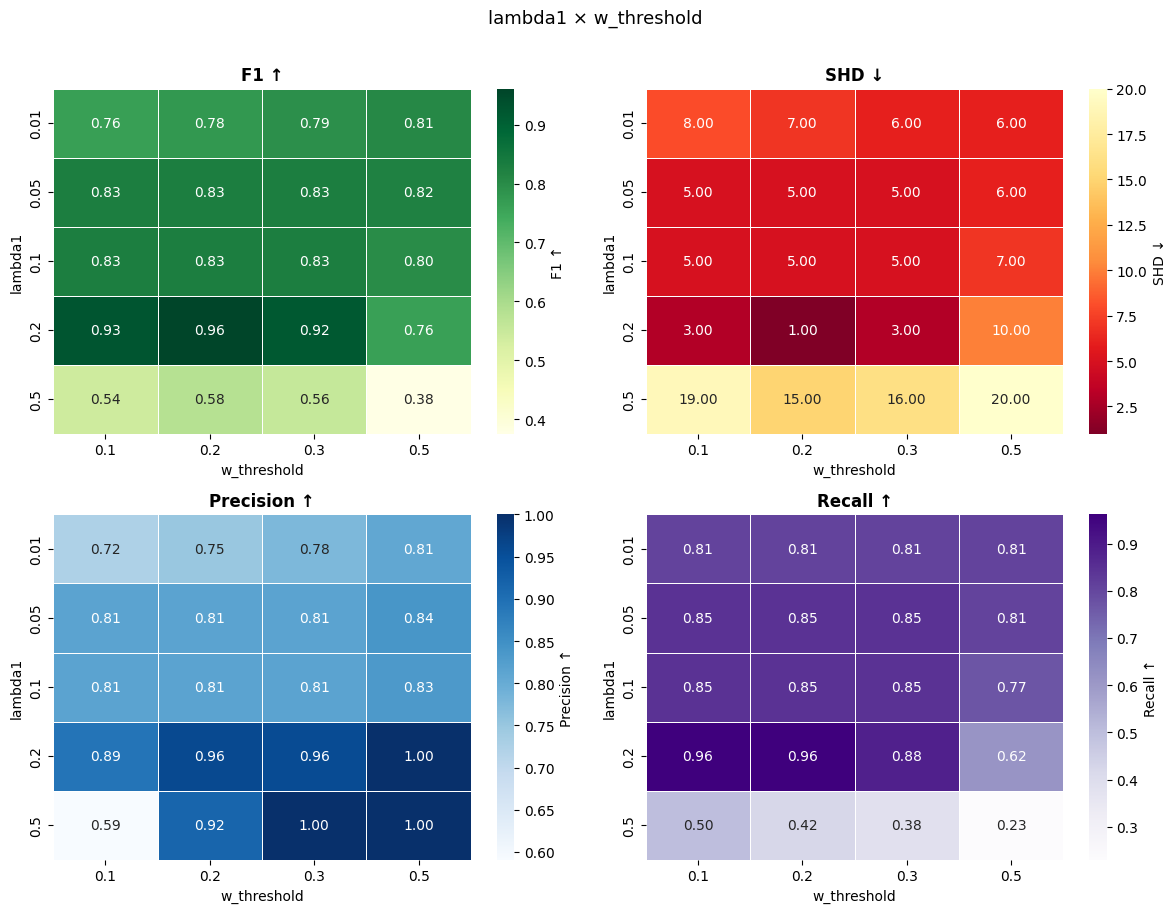

Saved → notears_gridsearch_heatmaps_lambda1_x_w_threshold.png


In [13]:
plot_heatmaps(results_df, PARAM_GRID)

2026-04-11 18:15:02,585 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:15:02,587 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:15:02,588 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:15:02,590 - c:\Users\danie\co

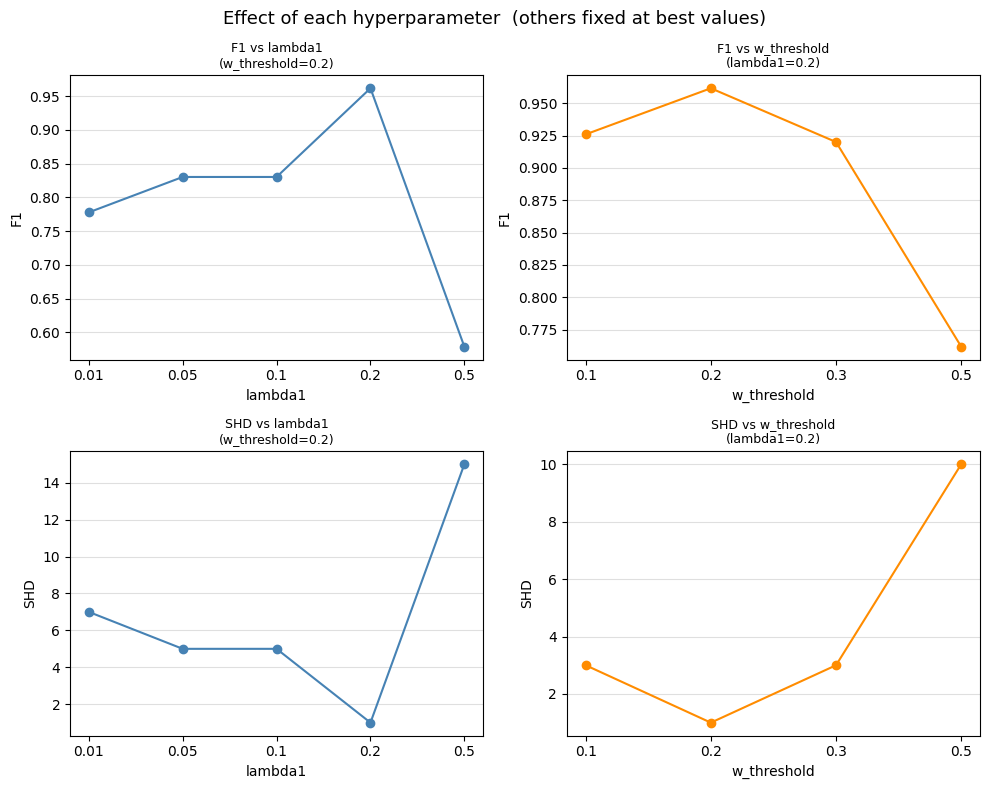

Saved → notears_gridsearch_profiles.png


In [14]:
plot_line_profiles(results_df, PARAM_GRID, best_params)

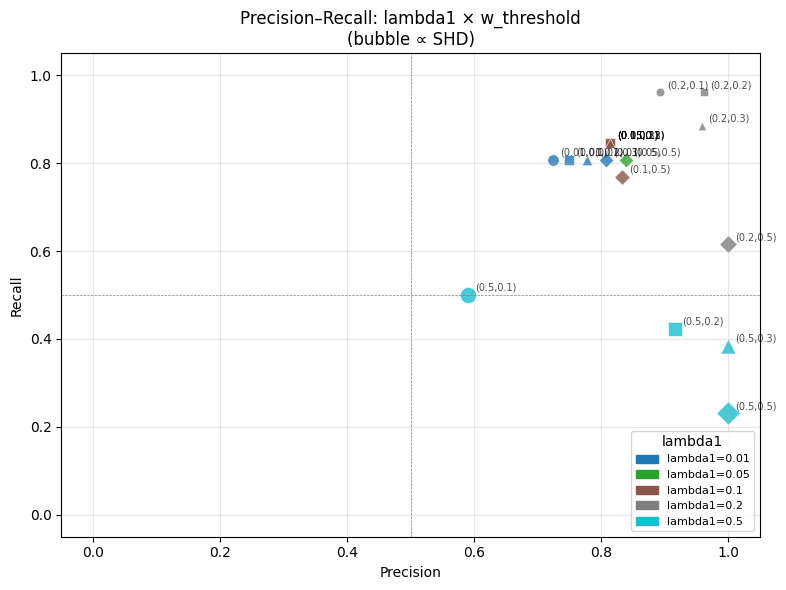

Saved → notears_gridsearch_scatter.png


In [15]:
plot_scatter(results_df, PARAM_GRID)

In [16]:
print_summary(results_df, PARAM_GRID)

Top 5 combinations by F1
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.20          0.2 0.962      0.962   0.962    1         26
    0.20          0.1 0.926      0.893   0.962    3         28
    0.20          0.3 0.920      0.958   0.885    3         24
    0.05          0.1 0.830      0.815   0.846    5         27
    0.10          0.2 0.830      0.815   0.846    5         27

Recommended: lambda1=0.2, w_threshold=0.2
  F1=0.962  Precision=0.962  Recall=0.962  SHD=1


## NOTEARS grid search over Sachs et al. dataset

Grid search over the following NOTEARS hyperparameters on the real Sachs et al. dataset:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `\|weight\| < w_threshold` are pruned |

The dataset consists of ~7,466 single-cell protein expression measurements across 14 experimental conditions (all conditions pooled). The ground truth is the 20-edge causal network from Sachs et al. (2005), covering 11 proteins and phospholipids. Note that the ground truth includes the bidirected edge PKA ↔ PIP3.

In [ ]:
sachs_df  = load_sachs_data()
sachs_dag = load_sachs_ground_truth()

SACHS_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}

print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")
best_result_sachs, results_df_sachs = grid_search(sachs_df, "notears", SACHS_PARAM_GRID, sachs_dag)

best_params_sachs = results_df_sachs.loc[results_df_sachs["shd"].idxmin(), list(SACHS_PARAM_GRID.keys())].to_dict()
print(f"Best SHD: {results_df_sachs['shd'].min():.0f}  params: {best_params_sachs}")
results_df_sachs

### Results

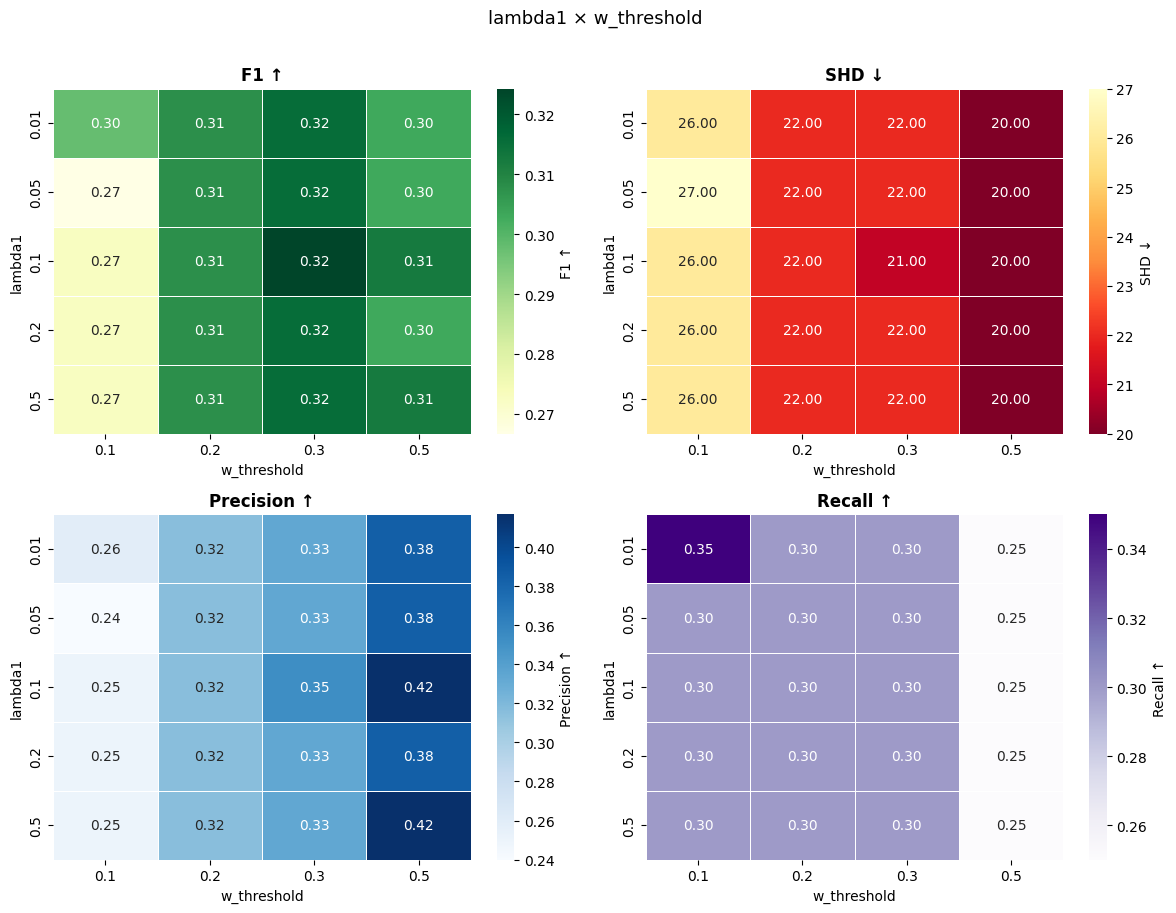

Saved → notears_gridsearch_heatmaps_lambda1_x_w_threshold.png


In [6]:
plot_heatmaps(results_df_sachs, SACHS_PARAM_GRID)

2026-04-11 18:39:16,682 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:39:16,683 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:39:16,685 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:39:16,686 - c:\Users\danie\co

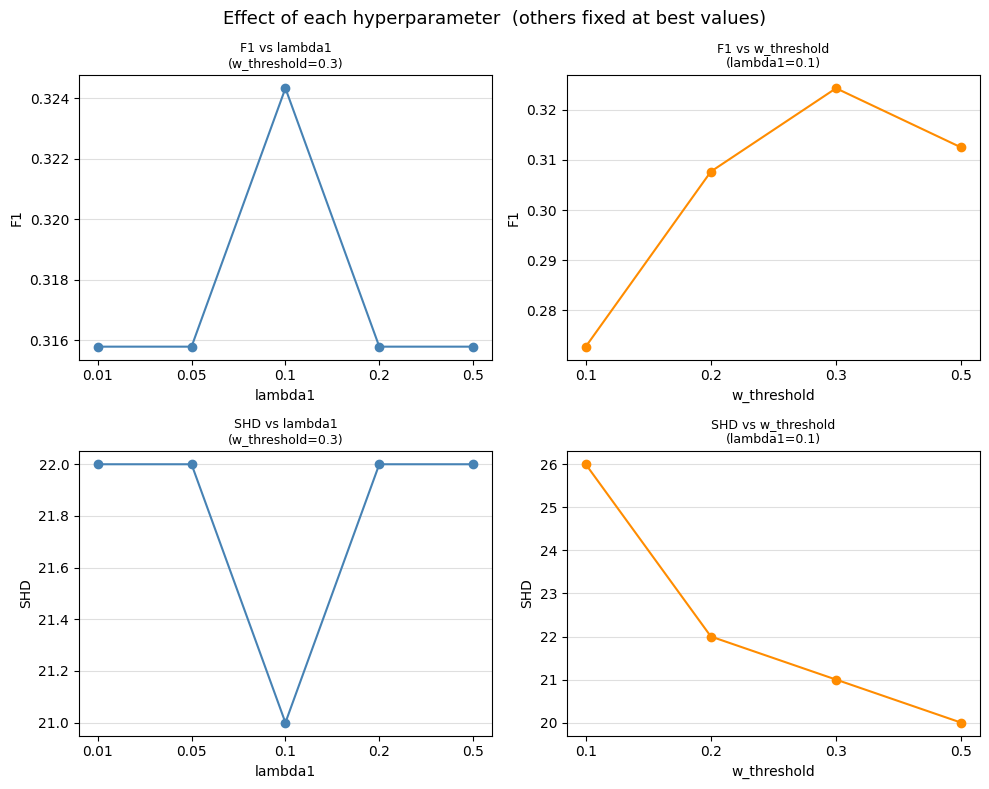

Saved → notears_gridsearch_profiles.png


In [7]:
plot_line_profiles(results_df_sachs, SACHS_PARAM_GRID, best_params_sachs)

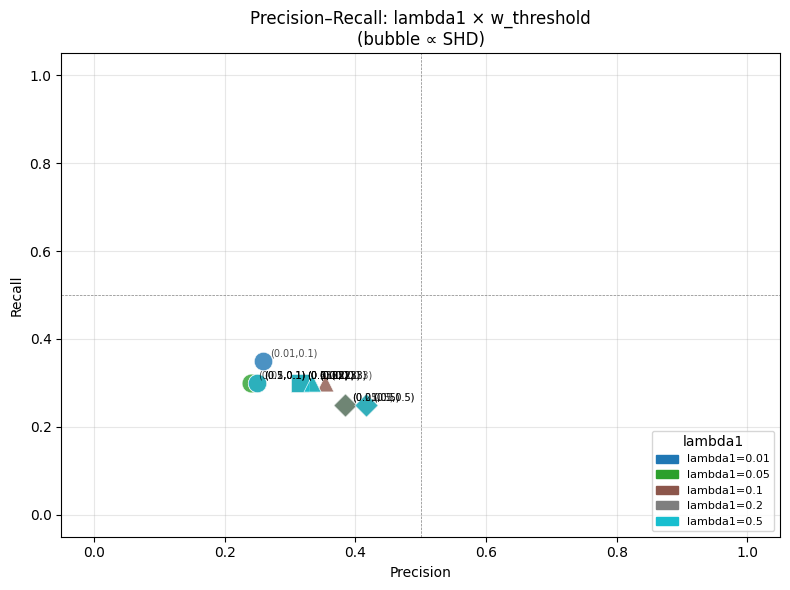

Saved → notears_gridsearch_scatter.png


In [8]:
plot_scatter(results_df_sachs, SACHS_PARAM_GRID)

In [9]:
print_summary(results_df_sachs, SACHS_PARAM_GRID)

Top 5 combinations by F1
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.10          0.3 0.324      0.353     0.3   21         17
    0.01          0.3 0.316      0.333     0.3   22         18
    0.05          0.3 0.316      0.333     0.3   22         18
    0.50          0.3 0.316      0.333     0.3   22         18
    0.20          0.3 0.316      0.333     0.3   22         18

Recommended: lambda1=0.1, w_threshold=0.3
  F1=0.324  Precision=0.353  Recall=0.300  SHD=21


## PC grid search over Sachs et al. dataset

Grid search over the following PC hyperparameters on the real Sachs et al. dataset:

| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (e.g. `"pearsonr"` for continuous Gaussian data, `"chi_square"` / `"g_sq"` for discrete) |
| `significance_level` | Alpha threshold — lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size — limits the depth of the skeleton-finding phase; `None` = no limit |

In [4]:
sachs_df  = load_sachs_data()
sachs_dag = load_sachs_ground_truth()

PC_SACHS_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}

print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")
best_result_pc_sachs, results_df_pc_sachs = grid_search(
    sachs_df, "pc", PC_SACHS_PARAM_GRID, sachs_dag
)

best_params_pc_sachs = results_df_pc_sachs.loc[
    results_df_pc_sachs["shd"].idxmin(), list(PC_SACHS_PARAM_GRID.keys())
].to_dict()
print(f"Best SHD: {results_df_pc_sachs['shd'].min():.0f}  params: {best_params_pc_sachs}")
results_df_pc_sachs

Sachs: 11672 samples, 11 nodes, 20 true edges
Grid: 1 × 6 × 4 = 24 combinations



2026-04-13 19:18:00,714 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\pgmpy\causal_discovery\_base.py[line:407] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-04-13 19:18:03,190 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\pgmpy\causal_discovery\_base.py[line:407] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-04-13 19:18:06,163 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\pgmpy\causal_discovery\_base.py[line:407] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-04-13 19:18:09,378 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\pgmpy\causal_discovery\_base.py[line:407] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-04-13 19:18:10,696 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\pgmpy\causal_discovery\_base.py[line:407] - INFO: Reached maximum number of allowed conditional vari

Best SHD: 24  params: {'ci_test': 'pearsonr', 'significance_level': 0.001, 'max_cond_vars': 4.0}


,ci_test,significance_level,max_cond_vars,n_learned,shd,precision,recall,f1
0,pearsonr,0.001,2.0,28,28,0.285714,0.363636,0.320000
1,pearsonr,0.001,3.0,25,28,0.280000,0.333333,0.304348
2,pearsonr,0.001,4.0,22,24,0.363636,0.400000,0.380952
3,pearsonr,0.001,NaN,23,26,0.304348,0.333333,0.318182
4,pearsonr,0.005,2.0,34,33,0.264706,0.360000,0.305085
5,pearsonr,0.005,3.0,28,28,0.285714,0.363636,0.320000
6,pearsonr,0.005,4.0,28,30,0.214286,0.272727,0.240000
7,pearsonr,0.005,NaN,26,30,0.192308,0.238095,0.212766
8,pearsonr,0.010,2.0,31,31,0.258065,0.363636,0.301887
9,pearsonr,0.010,3.0,33,33,0.242424,0.333333,0.280702


### Results

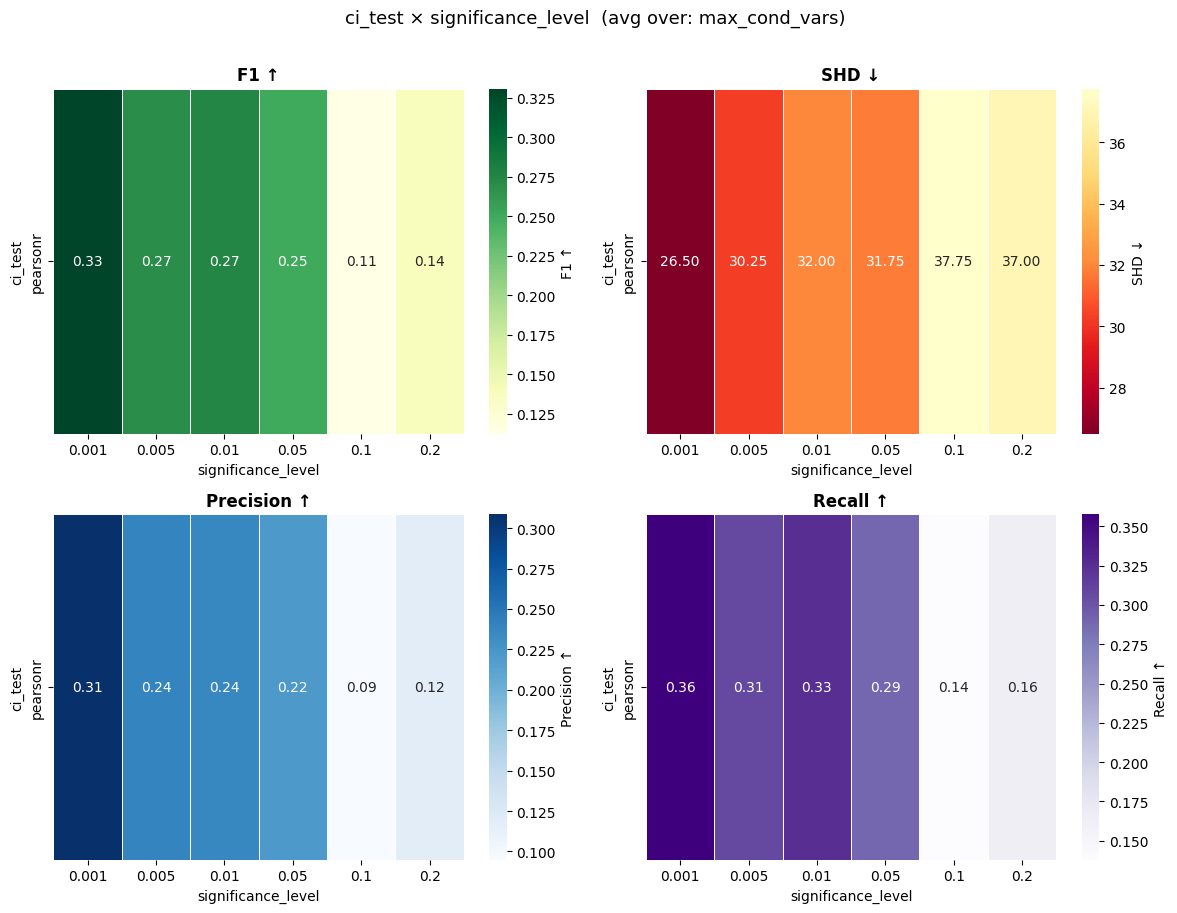

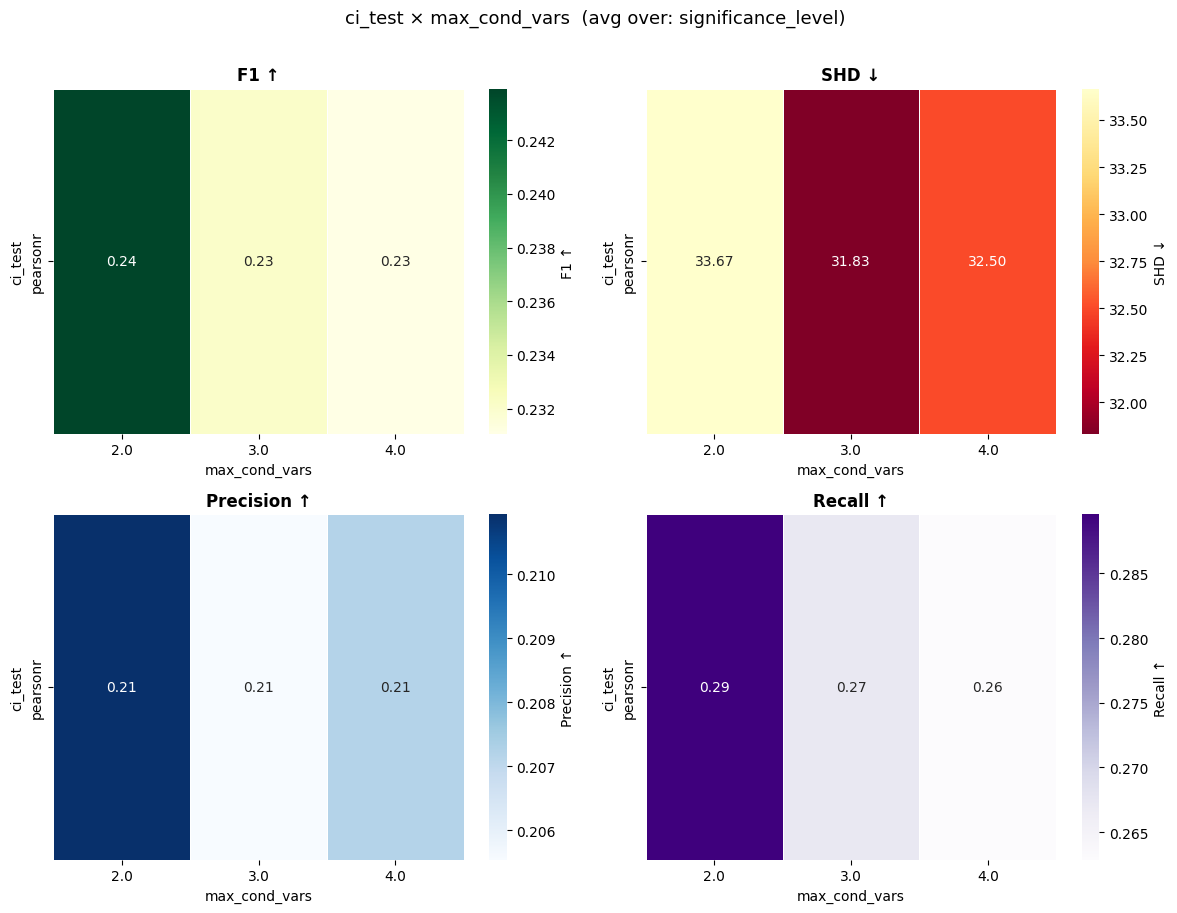

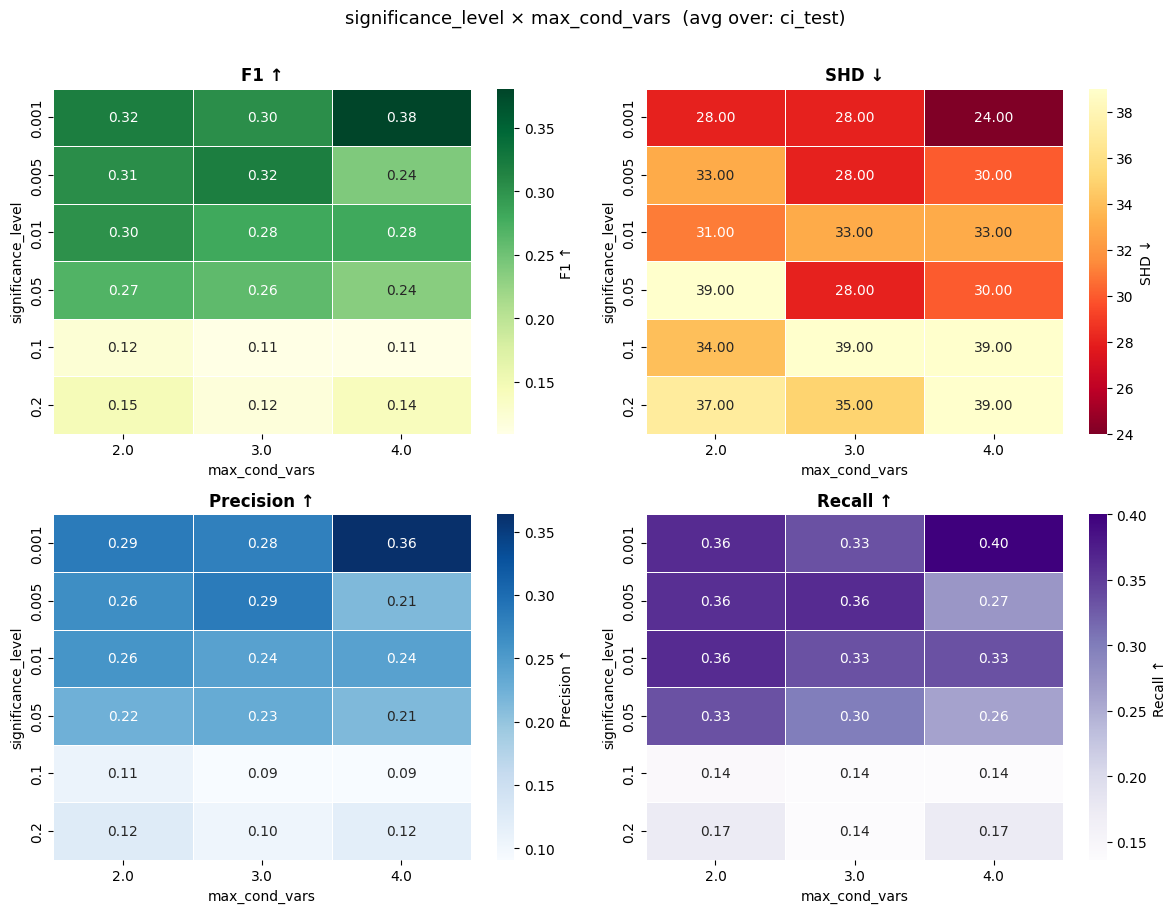

In [5]:
plot_heatmaps(results_df_pc_sachs, PC_SACHS_PARAM_GRID)

2026-04-13 19:19:12,493 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-13 19:19:12,497 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-13 19:19:12,503 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-13 19:19:12,505 - c:\Users\danie\co

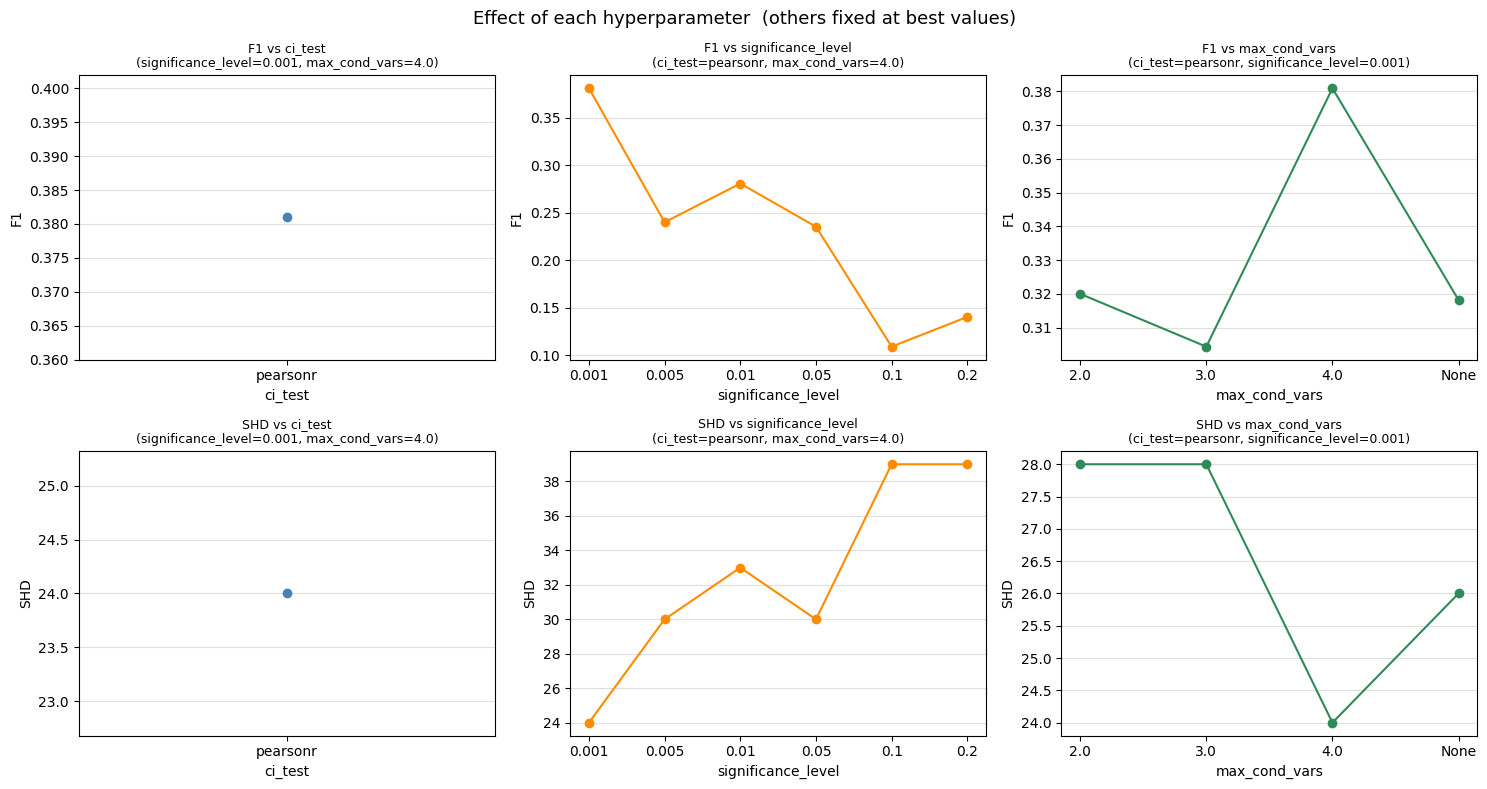

In [6]:
plot_line_profiles(results_df_pc_sachs, PC_SACHS_PARAM_GRID, best_params_pc_sachs)

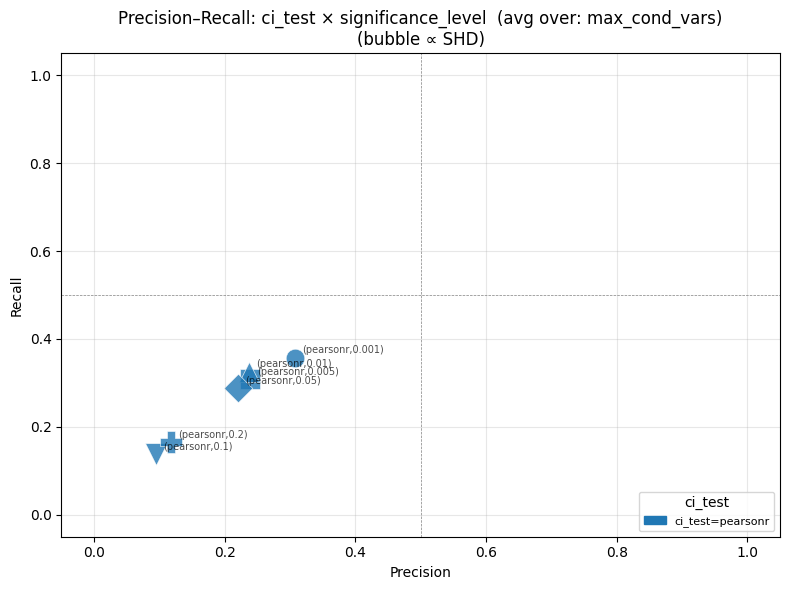

In [7]:
plot_scatter(results_df_pc_sachs, PC_SACHS_PARAM_GRID)

In [8]:
print_summary(results_df_pc_sachs, PC_SACHS_PARAM_GRID)

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.001            4.0 0.381      0.364   0.400   24         22
pearsonr               0.001            NaN 0.318      0.304   0.333   26         23
pearsonr               0.001            3.0 0.304      0.280   0.333   28         25
pearsonr               0.001            2.0 0.320      0.286   0.364   28         28
pearsonr               0.005            3.0 0.320      0.286   0.364   28         28

Recommended: ci_test=pearsonr, significance_level=0.001, max_cond_vars=4.0
  F1=0.381  Precision=0.364  Recall=0.400  SHD=24


## FGES grid search over Sachs et al. dataset

Grid search over the following GES hyperparameters on the real Sachs et al. dataset:

| Parameter | Role | Values |
|-----------|------|--------|
| `method` | BIC scoring variant | `scatter` (covariance-based), `r2` (adjusted R²) |

In [4]:
sachs_df  = load_sachs_data()
sachs_dag = load_sachs_ground_truth()

FGES_SACHS_PARAM_GRID = {
    "method": ["scatter", "r2"],
}

print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")
best_result_fges_sachs, results_df_fges_sachs = grid_search(
    sachs_df, "fges", FGES_SACHS_PARAM_GRID, sachs_dag
)

best_params_fges_sachs = results_df_fges_sachs.loc[
    results_df_fges_sachs["shd"].idxmin(), list(FGES_SACHS_PARAM_GRID.keys())
].to_dict()
print(f"Best SHD: {results_df_fges_sachs['shd'].min():.0f}  params: {best_params_fges_sachs}")
results_df_fges_sachs

Sachs: 11672 samples, 11 nodes, 20 true edges
Grid: 2 = 2 combinations

Best SHD: 26  params: {'method': 'r2'}


,method,n_learned,shd,precision,recall,f1
0,scatter,35,33,0.228571,0.363636,0.280702
1,r2,20,26,0.363636,0.285714,0.320000


### Results

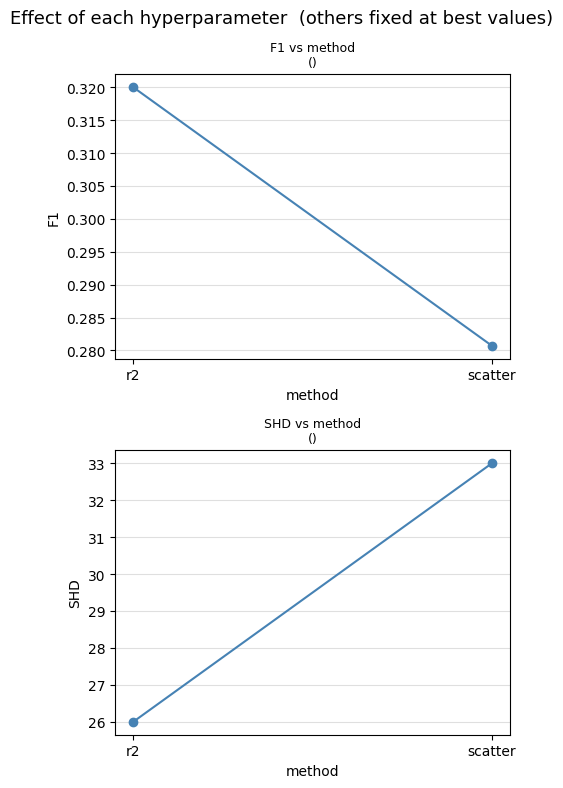

In [5]:
plot_line_profiles(results_df_fges_sachs, FGES_SACHS_PARAM_GRID, best_params_fges_sachs)

In [6]:
print_summary(results_df_fges_sachs, FGES_SACHS_PARAM_GRID)

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
     r2 0.320      0.364   0.286   26         20
scatter 0.281      0.229   0.364   33         35

Recommended: method=r2
  F1=0.320  Precision=0.364  Recall=0.286  SHD=26
